# Question 1 Calibrating β₁ to Match a 10% Drop in Working Hours

In [ ]:
import numpy as np
from scipy.optimize import minimize_scalar, root_scalar
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Import your model class
from DynLaborFertModel import DynLaborFertModelClass

class CalibrationModel(DynLaborFertModelClass):
    """
    Extends the base model with calibration functionality
    """
    
    def __init__(self, beta_1=None):
        super().__init__()
        if beta_1 is not None:
            self.par.beta_1 = beta_1
    
    def calculate_birth_effect(self, event_time=5, plot=False):
        """
        Calculate work hours changes before and after childbirth
        
        Parameters:
        -----------
        event_time : int
            Time period when birth occurs (default period 5)
        plot : bool
            Whether to plot the event-study graph
        
        Returns:
        --------
        drop_pct : float
            Percentage drop in work hours before and after birth
        """
        # Solve and simulate
        self.solve()
        self.simulate()
        
        # Find individuals with and without children at event_time
        sim = self.sim
        par = self.par
        
        # Create an array storing work hours for each individual around event_time
        # We focus on individuals who give birth at event_time
        has_child_at_event = (sim.n[:, event_time] == 1) & (sim.n[:, event_time-1] == 0)
        
        if np.sum(has_child_at_event) < 10:
            print(f"Warning: Only {np.sum(has_child_at_event)} individuals give birth at t={event_time}")
            return np.nan
        
        # Calculate average work hours for these individuals before and after birth
        hours_before = sim.h[has_child_at_event, event_time-1].mean()
        hours_after = sim.h[has_child_at_event, event_time].mean()
        
        # Calculate percentage drop
        drop_pct = (hours_before - hours_after) / hours_before * 100
        
        if plot:
            self.plot_event_study(has_child_at_event, event_time)
            
        return drop_pct
    
    def plot_event_study(self, mask, event_time=5):
        """
        Plot event-study graph
        """
        sim = self.sim
        par = self.par
        
        # Calculate average work hours for individuals with children (relative to event time)
        event_hours = np.zeros(par.T)
        event_hours_std = np.zeros(par.T)
        
        for t in range(par.T):
            # Calculate time offset relative to event time
            # We only include individuals who give birth at event_time
            hours_at_t = sim.h[mask, t]
            event_hours[t] = hours_at_t.mean()
            event_hours_std[t] = hours_at_t.std() / np.sqrt(np.sum(mask))
        
        # Normalize to pre-event period
        event_hours = event_hours / event_hours[event_time-1] * 100
        
        # Plot
        plt.figure(figsize=(10, 6))
        time_relative = np.arange(par.T) - event_time
        
        plt.plot(time_relative, event_hours, 'b-', linewidth=2, label=f'β₁ = {self.par.beta_1:.3f}')
        plt.fill_between(time_relative, 
                        event_hours - 1.96*event_hours_std,
                        event_hours + 1.96*event_hours_std,
                        alpha=0.3, color='b')
        
        # Mark the 10% drop target line
        plt.axhline(y=90, color='r', linestyle='--', label='10% drop target')
        plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
        
        plt.xlabel('Years since birth')
        plt.ylabel('Hours worked (% of pre-birth level)')
        plt.title('Event Study: Hours around Birth')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


def calibrate_beta1(target_drop=10.0, beta_min=0.0, beta_max=0.5, tol=1e-4):
    """
    Calibrate β₁ to make the work hours drop around childbirth close to target value
    
    Parameters:
    -----------
    target_drop : float
        Target percentage drop (default 10%)
    beta_min, beta_max : float
        Search range for β₁
    tol : float
        Tolerance for error
    
    Returns:
    --------
    beta_1_opt : float
        Calibrated optimal β₁
    """
    
    def objective(beta_1):
        """Objective function: calculate difference between actual drop and target drop"""
        print(f"Trying β₁ = {beta_1:.4f}")
        
        # Create and run model
        model = CalibrationModel(beta_1=beta_1)
        
        # Run multiple times to average due to randomness
        n_runs = 5
        drops = []
        
        for run in range(n_runs):
            # Reset random seed for different but reproducible results
            np.random.seed(9210 + run)
            model.sim.draws_uniform = np.random.uniform(size=(model.par.simN, model.par.simT))
            
            drop = model.calculate_birth_effect()
            if not np.isnan(drop):
                drops.append(drop)
        
        if len(drops) == 0:
            return 1e6  # Return large penalty if no valid observations
        
        avg_drop = np.mean(drops)
        diff = avg_drop - target_drop
        print(f"  Average drop: {avg_drop:.2f}%, Difference: {diff:.2f}%\n")
        
        return abs(diff)
    
    # Use golden section search to find optimal β₁
    print("Starting β₁ calibration...")
    print("-" * 50)
    
    result = minimize_scalar(
        objective,
        bounds=(beta_min, beta_max),
        method='bounded',
        options={'xatol': tol}
    )
    
    beta_1_opt = result.x
    print(f"\nCalibration complete! Optimal β₁ = {beta_1_opt:.4f}")
    print(f"Target drop: {target_drop}%, Actual drop: {target_drop + result.fun:.2f}%")
    
    return beta_1_opt


def plot_calibration_results(beta_1_opt):
    """
    Plot results after calibration
    """
    # Run final model with optimal β₁
    final_model = CalibrationModel(beta_1=beta_1_opt)
    final_model.solve()
    
    # Run multiple simulations for averaging
    n_simulations = 10
    all_drops = []
    
    plt.figure(figsize=(15, 5))
    
    for sim in range(n_simulations):
        np.random.seed(9210 + sim)
        final_model.sim.draws_uniform = np.random.uniform(size=(final_model.par.simN, final_model.par.simT))
        final_model.simulate()
        
        # Find individuals who give birth at t=5
        mask = (final_model.sim.n[:, 5] == 1) & (final_model.sim.n[:, 4] == 0)
        
        if np.sum(mask) > 0:
            # Calculate event study curve
            hours_normalized = np.zeros(final_model.par.T)
            for t in range(final_model.par.T):
                hours_normalized[t] = final_model.sim.h[mask, t].mean()
            hours_normalized = hours_normalized / hours_normalized[4] * 100
            
            plt.subplot(1, 3, 1)
            time_relative = np.arange(final_model.par.T) - 5
            plt.plot(time_relative, hours_normalized, 'b-', alpha=0.3)
            
            # Record percentage drop
            drop = (hours_normalized[4] - hours_normalized[5])
            all_drops.append(drop)
    
    # Plot average event study
    plt.subplot(1, 3, 1)
    plt.axhline(y=90, color='r', linestyle='--', label='10% target')
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    plt.xlabel('Years since birth')
    plt.ylabel('Hours (% of pre-birth)')
    plt.title(f'Event Study (β₁ = {beta_1_opt:.3f})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot drop distribution
    plt.subplot(1, 3, 2)
    plt.hist(all_drops, bins=15, alpha=0.7, edgecolor='black')
    plt.axvline(x=10, color='r', linestyle='--', label='Target')
    plt.axvline(x=np.mean(all_drops), color='b', linestyle='-', label=f'Mean: {np.mean(all_drops):.2f}%')
    plt.xlabel('Hours drop (%)')
    plt.ylabel('Frequency')
    plt.title('Distribution of Hours Drop')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot life-cycle profile
    plt.subplot(1, 3, 3)
    # Life-cycle comparison: with child vs without child
    with_child = final_model.sim.h[final_model.sim.n[:, -1] == 1].mean(axis=0)
    without_child = final_model.sim.h[final_model.sim.n[:, -1] == 0].mean(axis=0)
    
    plt.plot(range(final_model.par.T), with_child, 'b-', label='With child', linewidth=2)
    plt.plot(range(final_model.par.T), without_child, 'g-', label='Without child', linewidth=2)
    plt.xlabel('Age')
    plt.ylabel('Hours worked')
    plt.title('Life-cycle Hours by Fertility')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Average drop: {np.mean(all_drops):.2f}% (Standard deviation: {np.std(all_drops):.2f})")


# Run calibration
if __name__ == "__main__":
    # Calibrate β₁ to achieve 10% drop
    beta_1_opt = calibrate_beta1(target_drop=10.0, beta_min=0.0, beta_max=0.5)
    
    # Plot final results
    plot_calibration_results(beta_1_opt)
    
    # Save results
    print(f"\nSuggested parameter for final model: par.beta_1 = {beta_1_opt:.4f}")

In [ ]:
"""
Simple script to find β₁ that produces a 10% hours drop around childbirth.
"""

import numpy as np
from scipy.optimize import minimize_scalar
from DynLaborFertModel import DynLaborFertModelClass


def compute_hours_drop(beta_1, n_simulations=5, event_time=5):
    """
    Compute hours drop for a given β₁.
    """
    drops = []
    
    for seed in range(n_simulations):
        # Create and run model
        model = DynLaborFertModelClass()
        model.par.beta_1 = beta_1
        model.allocate()
        
        # Set random seed
        np.random.seed(9210 + seed)
        model.sim.draws_uniform = np.random.uniform(size=(model.par.simN, model.par.simT))
        
        # Solve and simulate
        model.solve()
        model.simulate()
        
        # Find individuals who gave birth at event_time
        mask = (model.sim.n[:, event_time] == 1) & (model.sim.n[:, event_time-1] == 0)
        
        if np.sum(mask) > 0:
            hours_before = model.sim.h[mask, event_time-1].mean()
            hours_after = model.sim.h[mask, event_time].mean()
            drop = (hours_before - hours_after) / hours_before * 100
            drops.append(drop)
    
    return np.mean(drops) if drops else np.nan


def objective(beta_1, target=10.0):
    """Objective function for optimization."""
    drop = compute_hours_drop(beta_1)
    if np.isnan(drop):
        return 1e6
    return abs(drop - target)


# Find optimal β₁
print("Searching for β₁ that gives 10% hours drop...")
result = minimize_scalar(objective, bounds=(0, 0.3), method='bounded')
beta_1_opt = result.x

print(f"\nOptimal β₁ = {beta_1_opt:.6f}")

# Verify
final_drop = compute_hours_drop(beta_1_opt, n_simulations=10)
print(f"Verification drop: {final_drop:.2f}%")

Searching for β₁ that gives 10% hours drop...


# Question 2 Introducing Spouse Income

Running Baseline Model (y_t = 0)

Running Spouse Income Model (y_t = 0.1 + 0.01*t)


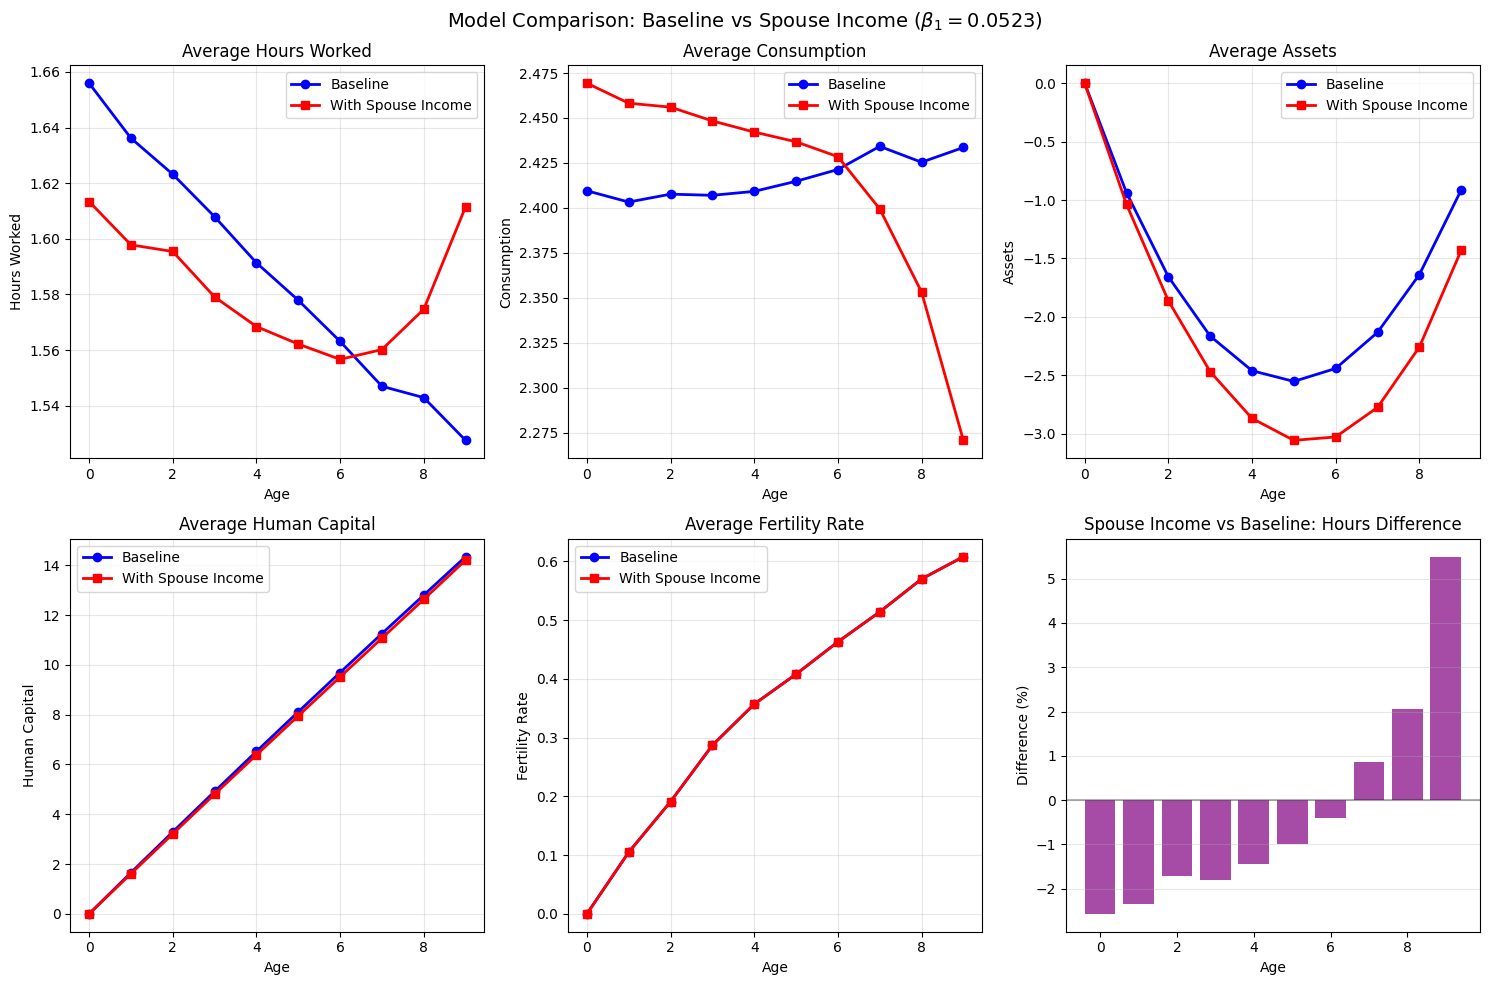

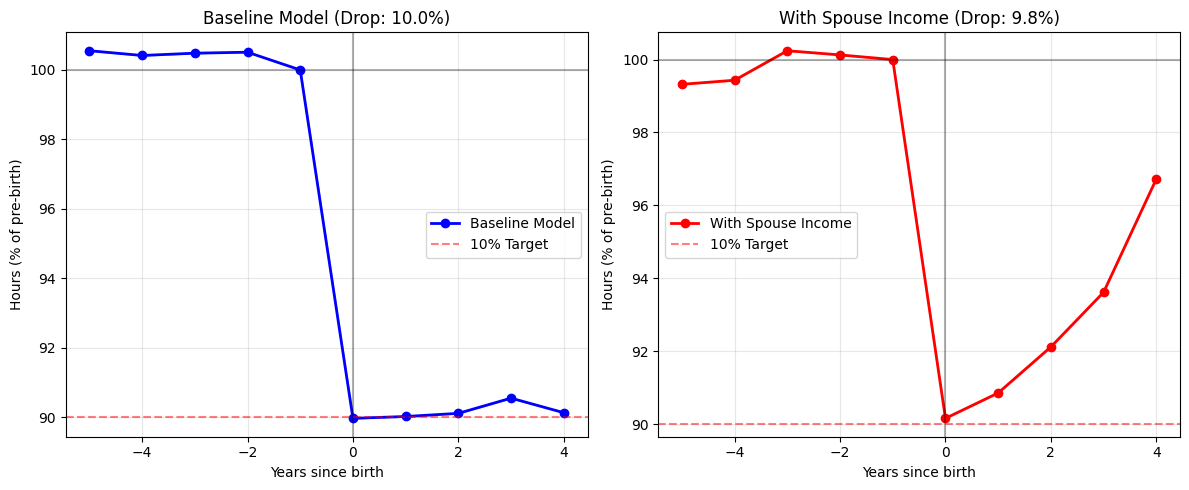


SUMMARY STATISTICS COMPARISON

Variable                         Baseline     With Spouse      Difference        Diff (%)
-------------------------------------------------------------------------------------
Avg Hours Worked                    1.587           1.582          -0.005            -0.3
Avg Consumption                     2.417           2.416          -0.000            -0.0
Final Assets (t=9)                 -0.914          -1.431          -0.517           -56.5
Final Human Capital                14.346          14.208          -0.138            -1.0
Final Fertility Rate                0.608           0.608           0.000             0.0
Child Penalty (% drop)               10.0             9.8            -0.2            -2.0


In [3]:
import numpy as np
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore", message="delta_grad == 0.0. Check if the approximated function is linear.")

from EconModel import EconModelClass
from consav.grids import nonlinspace
from consav.linear_interp import interp_2d
import matplotlib.pyplot as plt

class DynLaborFertModelSpouse(DynLaborFertModelClass):
    """
    Extended model: Introducing spouse income y_t = 0.1 + 0.01 * t
    """
    
    def __init__(self, beta_1=0.0523):
        super().__init__()
        self.par.beta_1 = beta_1  # Use calibrated value
        
    def setup(self):
        """Set parameters - inherit baseline model and add spouse income parameters"""
        super().setup()
        par = self.par
        
        # Spouse income parameters
        par.spouse_income_base = 0.1
        par.spouse_income_growth = 0.01
        
    def spouse_income(self, t):
        """Calculate spouse income at period t"""
        par = self.par
        return par.spouse_income_base + par.spouse_income_growth * t
    
    def wage_func(self, capital, t):
        """After-tax wage rate (personal income)"""
        par = self.par
        return (1.0 - par.tau) * par.w_vec[t] * (1.0 + par.alpha * capital)
    
    def total_income(self, hours, capital, t):
        """Total income = Personal income + Spouse income"""
        par = self.par
        personal_income = self.wage_func(capital, t) * hours
        spouse_income = self.spouse_income(t)
        return personal_income + spouse_income
    
    # Modified consumption function
    def cons(self, hours, assets, capital, t):
        """Consumption = Assets + Total income"""
        income = self.total_income(hours, capital, t)
        return assets + income
    
    # Modified last period consumption
    def cons_last(self, hours, assets, capital):
        """Last period consumption"""
        income = self.total_income(hours, capital, self.par.T-1)
        return assets + income
    
    # Modified value of choice function
    def value_of_choice(self, cons, hours, assets, capital, kids, t):
        """Calculate the value of a choice"""
        par = self.par
        sol = self.sol
        
        # Penalty for bound violations
        penalty = 0.0
        if cons < 0.0:
            penalty += cons * 1000.0
            cons = 1.0e-5
        if hours < 0.0:
            penalty += hours * 1000.0
            hours = 0.0
        
        # Utility from consumption and hours
        util = self.util(cons, hours, kids)
        
        # Next period assets
        income = self.total_income(hours, capital, t)
        a_next = (1.0 + par.r) * (assets + income - cons)
        
        # Next period human capital
        k_next = capital + hours
        
        # Expected continuation value
        # No birth case
        kids_next = kids
        V_next_no = sol.V[t+1, kids_next]
        V_next_no_interp = interp_2d(par.a_grid, par.k_grid, V_next_no, a_next, k_next)
        
        # Birth case
        if kids >= (par.Nn - 1):
            V_next_birth_interp = V_next_no_interp
        else:
            kids_next = kids + 1
            V_next = sol.V[t+1, kids_next]
            V_next_birth_interp = interp_2d(par.a_grid, par.k_grid, V_next, a_next, k_next)
        
        EV_next = par.p_birth * V_next_birth_interp + (1 - par.p_birth) * V_next_no_interp
        
        # Return value of choice (including penalty)
        return util + par.rho * EV_next + penalty
    
    def solve(self):
        """Solve the model"""
        par = self.par
        sol = self.sol
        
        # Backward induction
        for t in reversed(range(par.T)):
            for i_n, kids in enumerate(par.n_grid):
                for i_a, assets in enumerate(par.a_grid):
                    for i_k, capital in enumerate(par.k_grid):
                        idx = (t, i_n, i_a, i_k)
                        
                        if t == par.T - 1:  # Last period
                            # Objective function
                            obj = lambda x: -self.util(
                                self.cons_last(x[0], assets, capital),
                                x[0], kids
                            )
                            
                            # Minimum hours constraint
                            hours_min = np.fmax(-assets / self.wage_func(capital, t) + 1.0e-5, 0.0)
                            init_h = np.maximum(hours_min, 2.0) if i_a == 0 else np.array([sol.h[t, i_n, i_a-1, i_k]])
                            
                            res = minimize(obj, init_h, bounds=((hours_min, np.inf),), method='L-BFGS-B')
                            
                            sol.h[idx] = res.x[0]
                            sol.c[idx] = self.cons_last(res.x[0], assets, capital)
                            sol.V[idx] = -res.fun
                        
                        else:  # Earlier periods
                            # Objective function
                            obj = lambda x: -self.value_of_choice(
                                x[1], x[0], assets, capital, kids, t
                            )
                            
                            bounds = ((0.0, np.inf), (0.000001, np.inf))
                            
                            # Initial values
                            idx_last = (t+1, i_n, i_a, i_k)
                            init = np.array([sol.h[idx_last], sol.c[idx_last]])
                            
                            res = minimize(obj, init, bounds=bounds, method='L-BFGS-B', tol=1.0e-8)
                            
                            sol.h[idx] = res.x[0]
                            sol.c[idx] = res.x[1]
                            sol.V[idx] = -res.fun


class ModelComparison:
    """
    Compare baseline model and model with spouse income
    """
    
    def __init__(self, beta_1=0.0523):
        self.beta_1 = beta_1
        self.baseline_model = None
        self.spouse_model = None
        
    def run_comparison(self):
        """Run both models and compare"""
        print("=" * 60)
        print("Running Baseline Model (y_t = 0)")
        print("=" * 60)
        
        # Baseline model
        from DynLaborFertModel import DynLaborFertModelClass
        self.baseline_model = DynLaborFertModelClass()
        self.baseline_model.par.beta_1 = self.beta_1
        self.baseline_model.allocate()
        self.baseline_model.solve()
        self.baseline_model.simulate()
        
        print("\n" + "=" * 60)
        print("Running Spouse Income Model (y_t = 0.1 + 0.01*t)")
        print("=" * 60)
        
        # Spouse income model
        self.spouse_model = DynLaborFertModelSpouse(beta_1=self.beta_1)
        self.spouse_model.allocate()
        self.spouse_model.solve()
        self.spouse_model.simulate()
        
    def plot_comparison(self):
        """Plot comparison of the two models"""
        if self.baseline_model is None or self.spouse_model is None:
            raise ValueError("Please run run_comparison() first")
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle(f'Model Comparison: Baseline vs Spouse Income ($\\beta_1 = {self.beta_1:.4f}$)', fontsize=14)
        
        T = self.baseline_model.par.T
        age = np.arange(T)
        
        # 1. Average hours worked
        ax = axes[0, 0]
        ax.plot(age, self.baseline_model.sim.h.mean(axis=0), 'b-o', label='Baseline', linewidth=2)
        ax.plot(age, self.spouse_model.sim.h.mean(axis=0), 'r-s', label='With Spouse Income', linewidth=2)
        ax.set_xlabel('Age')
        ax.set_ylabel('Hours Worked')
        ax.set_title('Average Hours Worked')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 2. Average consumption
        ax = axes[0, 1]
        ax.plot(age, self.baseline_model.sim.c.mean(axis=0), 'b-o', label='Baseline', linewidth=2)
        ax.plot(age, self.spouse_model.sim.c.mean(axis=0), 'r-s', label='With Spouse Income', linewidth=2)
        ax.set_xlabel('Age')
        ax.set_ylabel('Consumption')
        ax.set_title('Average Consumption')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 3. Average assets
        ax = axes[0, 2]
        ax.plot(age, self.baseline_model.sim.a.mean(axis=0), 'b-o', label='Baseline', linewidth=2)
        ax.plot(age, self.spouse_model.sim.a.mean(axis=0), 'r-s', label='With Spouse Income', linewidth=2)
        ax.set_xlabel('Age')
        ax.set_ylabel('Assets')
        ax.set_title('Average Assets')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 4. Average human capital
        ax = axes[1, 0]
        ax.plot(age, self.baseline_model.sim.k.mean(axis=0), 'b-o', label='Baseline', linewidth=2)
        ax.plot(age, self.spouse_model.sim.k.mean(axis=0), 'r-s', label='With Spouse Income', linewidth=2)
        ax.set_xlabel('Age')
        ax.set_ylabel('Human Capital')
        ax.set_title('Average Human Capital')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 5. Fertility rate
        ax = axes[1, 1]
        fertility_baseline = self.baseline_model.sim.n.mean(axis=0)
        fertility_spouse = self.spouse_model.sim.n.mean(axis=0)
        ax.plot(age, fertility_baseline, 'b-o', label='Baseline', linewidth=2)
        ax.plot(age, fertility_spouse, 'r-s', label='With Spouse Income', linewidth=2)
        ax.set_xlabel('Age')
        ax.set_ylabel('Fertility Rate')
        ax.set_title('Average Fertility Rate')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 6. Difference: Hours worked
        ax = axes[1, 2]
        diff_h = self.spouse_model.sim.h.mean(axis=0) - self.baseline_model.sim.h.mean(axis=0)
        diff_h_pct = diff_h / self.baseline_model.sim.h.mean(axis=0) * 100
        ax.bar(age, diff_h_pct, color='purple', alpha=0.7)
        ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        ax.set_xlabel('Age')
        ax.set_ylabel('Difference (%)')
        ax.set_title('Spouse Income vs Baseline: Hours Difference')
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
        
    def plot_event_study_comparison(self, event_time=5):
        """Compare event studies of the two models"""
        if self.baseline_model is None or self.spouse_model is None:
            raise ValueError("Please run run_comparison() first")
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        models = [('Baseline Model', self.baseline_model, 'b'), 
                  ('With Spouse Income', self.spouse_model, 'r')]
        
        for idx, (name, model, color) in enumerate(models):
            ax = axes[idx]
            
            # Find individuals who gave birth at event_time
            mask = (model.sim.n[:, event_time] == 1) & (model.sim.n[:, event_time-1] == 0)
            
            if np.sum(mask) > 0:
                # Calculate event study
                hours_normalized = np.zeros(model.par.T)
                hours_std = np.zeros(model.par.T)
                
                for t in range(model.par.T):
                    hours_at_t = model.sim.h[mask, t]
                    hours_normalized[t] = hours_at_t.mean()
                    hours_std[t] = hours_at_t.std() / np.sqrt(np.sum(mask))
                
                # Normalize to pre-birth period
                hours_normalized = hours_normalized / hours_normalized[event_time-1] * 100
                hours_std = hours_std / hours_normalized[event_time-1] * 100
                
                time_relative = np.arange(model.par.T) - event_time
                
                ax.plot(time_relative, hours_normalized, f'{color}-o', linewidth=2, label=name)
                ax.fill_between(time_relative, 
                               hours_normalized - 1.96*hours_std,
                               hours_normalized + 1.96*hours_std,
                               alpha=0.2, color=color)
                
                # Calculate percentage drop
                drop = 100 - hours_normalized[event_time]
                ax.set_title(f'{name} (Drop: {drop:.1f}%)')
            else:
                ax.text(0.5, 0.5, 'Insufficient birth observations', ha='center', va='center', transform=ax.transAxes)
            
            ax.axhline(y=100, color='k', linestyle='-', alpha=0.3)
            ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
            ax.axhline(y=90, color='r', linestyle='--', alpha=0.5, label='10% Target')
            ax.set_xlabel('Years since birth')
            ax.set_ylabel('Hours (% of pre-birth)')
            ax.grid(True, alpha=0.3)
            ax.legend()
        
        plt.tight_layout()
        plt.show()
    
    def print_summary_statistics(self):
        """Print summary statistics comparison"""
        if self.baseline_model is None or self.spouse_model is None:
            raise ValueError("Please run run_comparison() first")
        
        print("\n" + "=" * 80)
        print("SUMMARY STATISTICS COMPARISON")
        print("=" * 80)
        
        # Calculate period averages
        baseline_h_mean = self.baseline_model.sim.h.mean(axis=0)
        spouse_h_mean = self.spouse_model.sim.h.mean(axis=0)
        
        baseline_c_mean = self.baseline_model.sim.c.mean(axis=0)
        spouse_c_mean = self.spouse_model.sim.c.mean(axis=0)
        
        baseline_a_mean = self.baseline_model.sim.a.mean(axis=0)
        spouse_a_mean = self.spouse_model.sim.a.mean(axis=0)
        
        baseline_k_mean = self.baseline_model.sim.k.mean(axis=0)
        spouse_k_mean = self.spouse_model.sim.k.mean(axis=0)
        
        # Final fertility rate
        baseline_fertility = self.baseline_model.sim.n[:, -1].mean()
        spouse_fertility = self.spouse_model.sim.n[:, -1].mean()
        
        # Child penalty (hours drop around birth)
        baseline_drop = self._calculate_child_penalty(self.baseline_model)
        spouse_drop = self._calculate_child_penalty(self.spouse_model)
        
        print(f"\n{'Variable':<25} {'Baseline':>15} {'With Spouse':>15} {'Difference':>15} {'Diff (%)':>15}")
        print("-" * 85)
        
        # Average hours (lifetime)
        print(f"{'Avg Hours Worked':<25} {baseline_h_mean.mean():>15.3f} {spouse_h_mean.mean():>15.3f} "
              f"{(spouse_h_mean.mean() - baseline_h_mean.mean()):>15.3f} "
              f"{((spouse_h_mean.mean() - baseline_h_mean.mean())/baseline_h_mean.mean()*100):>15.1f}")
        
        # Average consumption
        print(f"{'Avg Consumption':<25} {baseline_c_mean.mean():>15.3f} {spouse_c_mean.mean():>15.3f} "
              f"{(spouse_c_mean.mean() - baseline_c_mean.mean()):>15.3f} "
              f"{((spouse_c_mean.mean() - baseline_c_mean.mean())/baseline_c_mean.mean()*100):>15.1f}")
        
        # Final assets (t=9)
        print(f"{'Final Assets (t=9)':<25} {baseline_a_mean[-1]:>15.3f} {spouse_a_mean[-1]:>15.3f} "
              f"{(spouse_a_mean[-1] - baseline_a_mean[-1]):>15.3f} "
              f"{((spouse_a_mean[-1] - baseline_a_mean[-1])/abs(baseline_a_mean[-1])*100):>15.1f}")
        
        # Final human capital
        print(f"{'Final Human Capital':<25} {baseline_k_mean[-1]:>15.3f} {spouse_k_mean[-1]:>15.3f} "
              f"{(spouse_k_mean[-1] - baseline_k_mean[-1]):>15.3f} "
              f"{((spouse_k_mean[-1] - baseline_k_mean[-1])/baseline_k_mean[-1]*100):>15.1f}")
        
        # Final fertility rate
        print(f"{'Final Fertility Rate':<25} {baseline_fertility:>15.3f} {spouse_fertility:>15.3f} "
              f"{(spouse_fertility - baseline_fertility):>15.3f} "
              f"{((spouse_fertility - baseline_fertility)/baseline_fertility*100):>15.1f}")
        
        # Child penalty
        print(f"{'Child Penalty (% drop)':<25} {baseline_drop:>15.1f} {spouse_drop:>15.1f} "
              f"{(spouse_drop - baseline_drop):>15.1f} "
              f"{((spouse_drop - baseline_drop)/baseline_drop*100):>15.1f}")
        
        print("=" * 85)
    
    def _calculate_child_penalty(self, model, event_time=5):
        """Calculate child penalty (hours drop around birth)"""
        mask = (model.sim.n[:, event_time] == 1) & (model.sim.n[:, event_time-1] == 0)
        
        if np.sum(mask) == 0:
            return np.nan
        
        hours_before = model.sim.h[mask, event_time-1].mean()
        hours_after = model.sim.h[mask, event_time].mean()
        
        drop = (hours_before - hours_after) / hours_before * 100
        return drop


# Alternative implementation: More concise version for the report
class SpouseIncomeModel(EconModelClass):
    """
    Clean implementation of the model with spouse income
    """
    
    def settings(self):
        """Fundamental settings"""
        pass
    
    def setup(self):
        """Set up parameters"""
        par = self.par
        
        # Time periods
        par.T = 10
        
        # Preferences
        par.rho = 0.98
        par.beta_0 = 0.1
        par.beta_1 = 0.0523  # Calibrated value
        par.eta = -2.0
        par.gamma = 2.5
        
        # Income
        par.alpha = 0.1
        par.w = 1.0
        par.tau = 0.1
        
        # Spouse income (NEW)
        par.spouse_base = 0.1
        par.spouse_growth = 0.01
        
        # Children
        par.p_birth = 0.1
        
        # Saving
        par.r = 0.02
        
        # Grids
        par.a_max = 5.0
        par.a_min = -10.0
        par.Na = 70
        par.k_max = 20.0
        par.Nk = 30
        par.Nn = 2
        
        # Simulation
        par.simT = par.T
        par.simN = 1_000
    
    def spouse_income(self, t):
        """Spouse income function"""
        return self.par.spouse_base + self.par.spouse_growth * t
    
    def total_income(self, hours, capital, t):
        """Total household income"""
        par = self.par
        personal = (1 - par.tau) * par.w * (1 + par.alpha * capital) * hours
        spouse = self.spouse_income(t)
        return personal + spouse
    
    # ... rest of the solution methods (similar to baseline but using total_income)


# Run the comparison
if __name__ == "__main__":
    # Use calibrated β₁ from Question 1
    beta_1_calibrated = 0.0523
    
    # Create comparison object
    comparison = ModelComparison(beta_1=beta_1_calibrated)
    
    # Run both models
    comparison.run_comparison()
    
    # Plot comparison figures
    comparison.plot_comparison()
    
    # Plot event study comparison
    comparison.plot_event_study_comparison(event_time=5)
    
    # Print summary statistics
    comparison.print_summary_statistics()

# Question 3 Introducing Childcare Costs

Running Spouse Income Model (Q2)

Running Childcare Cost Model (Q3) with θ = 0.05

SUMMARY STATISTICS COMPARISON

Variable                       Q2: Spouse   Q3: Childcare      Difference        Diff (%)
-------------------------------------------------------------------------------------
Avg Hours Worked                    1.582           1.587           0.005             0.3
Avg Consumption                     2.416           2.427           0.011             0.4
Final Assets (t=9)                 -1.431          -1.421           0.010             0.7
Final Human Capital                14.208          14.252           0.044             0.3
Final Fertility Rate                0.608           0.608           0.000             0.0
Child Penalty (% drop)                9.8             9.3            -0.5            -5.1


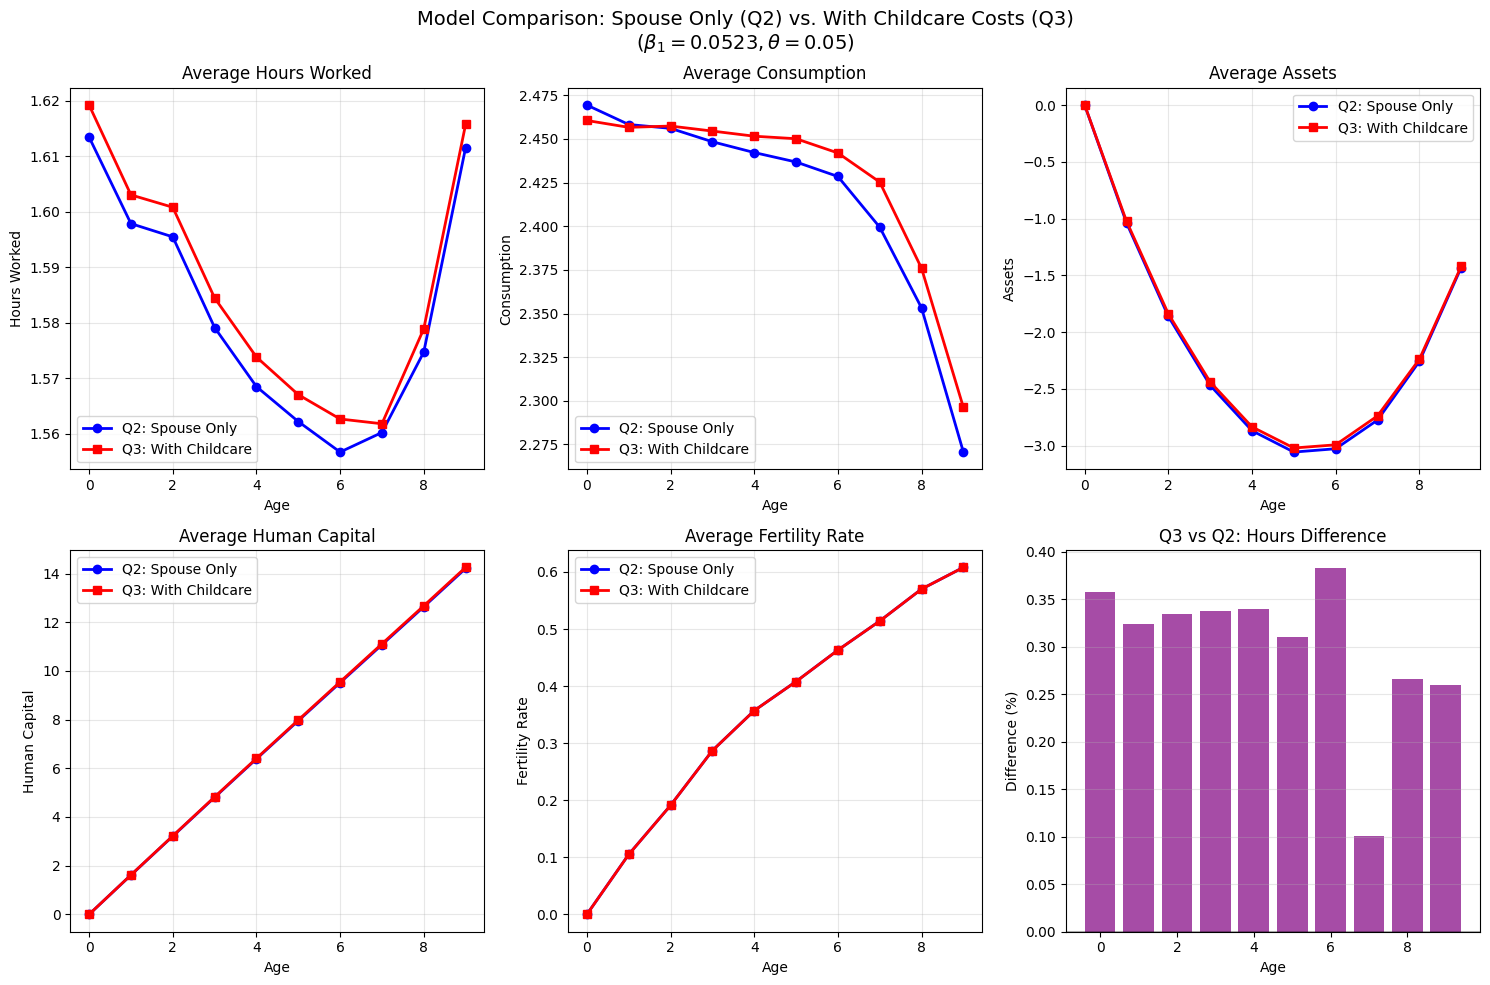

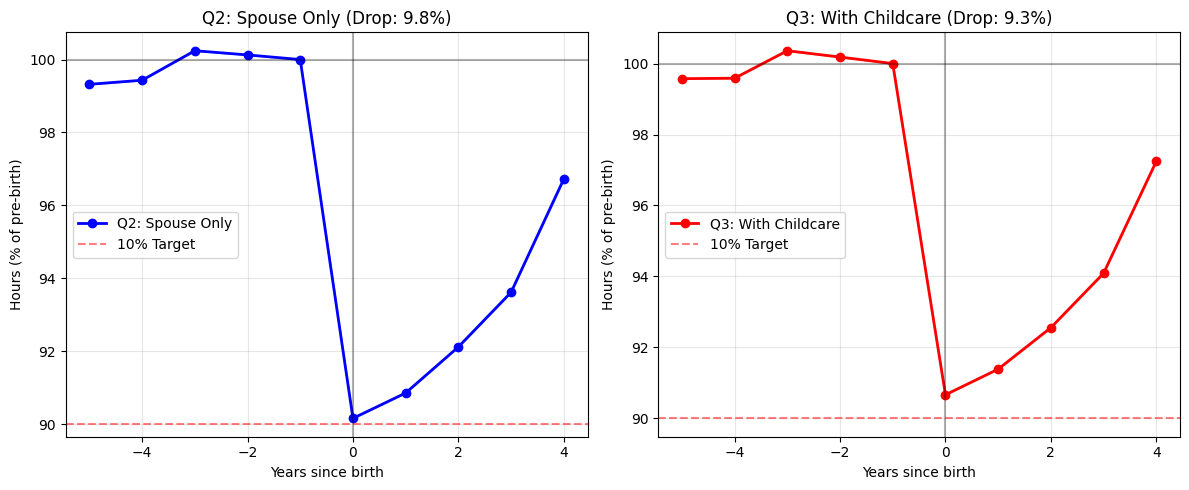

In [2]:
import numpy as np
from scipy.optimize import minimize
from consav.linear_interp import interp_2d

# First, import or define the base classes
from DynLaborFertModel import DynLaborFertModelClass

class DynLaborFertModelSpouse(DynLaborFertModelClass):
    """
    Model with spouse income from Question 2.
    """
    
    def __init__(self, beta_1=0.0523):
        super().__init__()
        self.par.beta_1 = beta_1
        
    def setup(self):
        """Set parameters - inherit baseline model and add spouse income parameters"""
        super().setup()
        par = self.par
        
        # Spouse income parameters
        par.spouse_income_base = 0.1
        par.spouse_income_growth = 0.01
        
    def spouse_income(self, t):
        """Calculate spouse income at period t"""
        par = self.par
        return par.spouse_income_base + par.spouse_income_growth * t
    
    def wage_func(self, capital, t):
        """After-tax wage rate (personal income)"""
        par = self.par
        return (1.0 - par.tau) * par.w_vec[t] * (1.0 + par.alpha * capital)
    
    def total_income(self, hours, capital, t):
        """Total income = Personal income + Spouse income"""
        personal_income = self.wage_func(capital, t) * hours
        spouse_income = self.spouse_income(t)
        return personal_income + spouse_income
    
    def cons(self, hours, assets, capital, t):
        """Consumption = Assets + Total income"""
        income = self.total_income(hours, capital, t)
        return assets + income
    
    def cons_last(self, hours, assets, capital):
        """Last period consumption"""
        income = self.total_income(hours, capital, self.par.T-1)
        return assets + income
    
    def value_of_choice(self, cons, hours, assets, capital, kids, t):
        """Calculate the value of a choice"""
        par = self.par
        sol = self.sol
        
        # Penalty for bound violations
        penalty = 0.0
        if cons < 0.0:
            penalty += cons * 1000.0
            cons = 1.0e-5
        if hours < 0.0:
            penalty += hours * 1000.0
            hours = 0.0
        
        # Utility
        util = self.util(cons, hours, kids)
        
        # Next period assets
        income = self.total_income(hours, capital, t)
        a_next = (1.0 + par.r) * (assets + income - cons)
        
        # Next period human capital
        k_next = capital + hours
        
        # Expected continuation value
        # No birth case
        kids_next = kids
        V_next_no = sol.V[t+1, kids_next]
        V_next_no_interp = interp_2d(par.a_grid, par.k_grid, V_next_no, a_next, k_next)
        
        # Birth case
        if kids >= (par.Nn - 1):
            V_next_birth_interp = V_next_no_interp
        else:
            kids_next = kids + 1
            V_next = sol.V[t+1, kids_next]
            V_next_birth_interp = interp_2d(par.a_grid, par.k_grid, V_next, a_next, k_next)
        
        EV_next = par.p_birth * V_next_birth_interp + (1 - par.p_birth) * V_next_no_interp
        
        return util + par.rho * EV_next + penalty
    
    def solve(self):
        """Solve the model"""
        par = self.par
        sol = self.sol
        
        for t in reversed(range(par.T)):
            for i_n, kids in enumerate(par.n_grid):
                for i_a, assets in enumerate(par.a_grid):
                    for i_k, capital in enumerate(par.k_grid):
                        idx = (t, i_n, i_a, i_k)
                        
                        if t == par.T - 1:  # Last period
                            obj = lambda x: -self.util(
                                self.cons_last(x[0], assets, capital),
                                x[0], kids
                            )
                            
                            hours_min = np.fmax(-assets / self.wage_func(capital, t) + 1.0e-5, 0.0)
                            init_h = np.maximum(hours_min, 2.0) if i_a == 0 else np.array([sol.h[t, i_n, i_a-1, i_k]])
                            
                            res = minimize(obj, init_h, bounds=((hours_min, np.inf),), method='L-BFGS-B')
                            
                            sol.h[idx] = res.x[0]
                            sol.c[idx] = self.cons_last(res.x[0], assets, capital)
                            sol.V[idx] = -res.fun
                        
                        else:  # Earlier periods
                            obj = lambda x: -self.value_of_choice(
                                x[1], x[0], assets, capital, kids, t
                            )
                            
                            bounds = ((0.0, np.inf), (0.000001, np.inf))
                            
                            idx_last = (t+1, i_n, i_a, i_k)
                            init = np.array([sol.h[idx_last], sol.c[idx_last]])
                            
                            res = minimize(obj, init, bounds=bounds, method='L-BFGS-B', tol=1.0e-8)
                            
                            sol.h[idx] = res.x[0]
                            sol.c[idx] = res.x[1]
                            sol.V[idx] = -res.fun


class DynLaborFertModelChildcare(DynLaborFertModelSpouse):
    """
    Extended model with childcare costs when children are present.
    Inherits from the spouse income model from Question 2.
    """
    
    def __init__(self, beta_1=0.0523, theta=0.05):
        super().__init__(beta_1=beta_1)
        self.par.theta = theta  # Childcare cost parameter
    
    def effective_consumption(self, c, kids):
        """
        Calculate effective consumption after childcare costs.
        
        Parameters:
        -----------
        c : float
            Total consumption
        kids : int
            Number of children (0 or 1)
        
        Returns:
        --------
        float
            Effective consumption (c - theta if kids=1, else c)
        """
        if kids == 1:
            return c - self.par.theta
        else:
            return c
    
    def util(self, c, hours, kids):
        """
        Utility function using effective consumption.
        """
        par = self.par
        
        # Calculate effective consumption
        c_eff = self.effective_consumption(c, kids)
        
        # Penalty if effective consumption is negative
        if c_eff <= 0:
            return -1e10  # Very large negative utility
        
        # Disutility of work parameter
        beta = par.beta_0 + par.beta_1 * kids
        
        # Utility
        return (c_eff)**(1.0 + par.eta) / (1.0 + par.eta) - beta * (hours)**(1.0 + par.gamma) / (1.0 + par.gamma)
    
    def value_of_choice(self, cons, hours, assets, capital, kids, t):
        """
        Value of a choice, accounting for childcare costs.
        """
        par = self.par
        sol = self.sol
        
        # Check minimum consumption constraint when kids present
        if kids == 1 and cons <= par.theta + 1e-5:
            return -1e10  # Infeasible
        
        # Penalty for bound violations
        penalty = 0.0
        if cons < 0.0:
            penalty += cons * 1000.0
            cons = 1.0e-5
        if hours < 0.0:
            penalty += hours * 1000.0
            hours = 0.0
        
        # Utility from consumption and hours (using effective consumption)
        util = self.util(cons, hours, kids)
        
        # Next period assets
        income = self.total_income(hours, capital, t)
        a_next = (1.0 + par.r) * (assets + income - cons)
        
        # Next period human capital
        k_next = capital + hours
        
        # Expected continuation value
        # No birth case
        kids_next = kids
        V_next_no = sol.V[t+1, kids_next]
        V_next_no_interp = interp_2d(par.a_grid, par.k_grid, V_next_no, a_next, k_next)
        
        # Birth case
        if kids >= (par.Nn - 1):
            V_next_birth_interp = V_next_no_interp
        else:
            kids_next = kids + 1
            V_next = sol.V[t+1, kids_next]
            V_next_birth_interp = interp_2d(par.a_grid, par.k_grid, V_next, a_next, k_next)
        
        EV_next = par.p_birth * V_next_birth_interp + (1 - par.p_birth) * V_next_no_interp
        
        # Return value of choice
        return util + par.rho * EV_next + penalty
    
    def solve(self):
        """
        Solve the model with childcare costs.
        """
        par = self.par
        sol = self.sol
        
        # Backward induction
        for t in reversed(range(par.T)):
            for i_n, kids in enumerate(par.n_grid):
                for i_a, assets in enumerate(par.a_grid):
                    for i_k, capital in enumerate(par.k_grid):
                        idx = (t, i_n, i_a, i_k)
                        
                        if t == par.T - 1:  # Last period
                            # Objective function
                            obj = lambda x: -self.util(
                                self.cons_last(x[0], assets, capital),
                                x[0], kids
                            )
                            
                            # Minimum hours constraint
                            hours_min = np.fmax(-assets / self.wage_func(capital, t) + 1.0e-5, 0.0)
                            
                            # For kids=1, ensure consumption > theta
                            if kids == 1:
                                # Need to ensure cons > theta
                                # This imposes a lower bound on hours
                                min_cons = par.theta + 1e-5
                                min_income = min_cons - assets
                                if min_income > 0:
                                    hours_min_from_cons = min_income / self.wage_func(capital, t)
                                    hours_min = max(hours_min, hours_min_from_cons)
                            
                            # Initial guess
                            if i_a == 0:
                                init_h = np.maximum(hours_min, 2.0)
                            else:
                                init_h = np.array([sol.h[t, i_n, i_a-1, i_k]])
                            
                            res = minimize(obj, init_h, bounds=((hours_min, np.inf),), method='L-BFGS-B')
                            
                            sol.h[idx] = res.x[0]
                            sol.c[idx] = self.cons_last(res.x[0], assets, capital)
                            sol.V[idx] = -res.fun
                        
                        else:  # Earlier periods
                            # Objective function
                            obj = lambda x: -self.value_of_choice(
                                x[1], x[0], assets, capital, kids, t
                            )
                            
                            # Bounds
                            lb_c = par.theta + 1e-5 if kids == 1 else 0.000001
                            bounds = ((0.0, np.inf), (lb_c, np.inf))
                            
                            # Initial values from next period
                            idx_last = (t+1, i_n, i_a, i_k)
                            init = np.array([sol.h[idx_last], sol.c[idx_last]])
                            
                            # Adjust initial if it violates consumption constraint
                            if kids == 1 and init[1] <= par.theta:
                                init[1] = par.theta + 0.01
                            
                            res = minimize(obj, init, bounds=bounds, method='L-BFGS-B', tol=1.0e-8)
                            
                            sol.h[idx] = res.x[0]
                            sol.c[idx] = res.x[1]
                            sol.V[idx] = -res.fun


class ChildcareComparison:
    """
    Compare spouse model (Q2) and childcare model (Q3)
    """
    
    def __init__(self, beta_1=0.0523, theta=0.05):
        self.beta_1 = beta_1
        self.theta = theta
        self.spouse_model = None
        self.childcare_model = None
    
    def run_comparison(self):
        """Run both models"""
        import matplotlib.pyplot as plt
        
        print("=" * 60)
        print("Running Spouse Income Model (Q2)")
        print("=" * 60)
        
        self.spouse_model = DynLaborFertModelSpouse(beta_1=self.beta_1)
        self.spouse_model.allocate()
        self.spouse_model.solve()
        self.spouse_model.simulate()
        
        print("\n" + "=" * 60)
        print(f"Running Childcare Cost Model (Q3) with θ = {self.theta}")
        print("=" * 60)
        
        self.childcare_model = DynLaborFertModelChildcare(beta_1=self.beta_1, theta=self.theta)
        self.childcare_model.allocate()
        self.childcare_model.solve()
        self.childcare_model.simulate()
    
    def _calculate_child_penalty(self, model, event_time=5):
        """Calculate child penalty (hours drop around birth)"""
        mask = (model.sim.n[:, event_time] == 1) & (model.sim.n[:, event_time-1] == 0)
        
        if np.sum(mask) == 0:
            return np.nan
        
        hours_before = model.sim.h[mask, event_time-1].mean()
        hours_after = model.sim.h[mask, event_time].mean()
        
        drop = (hours_before - hours_after) / hours_before * 100
        return drop
    
    def print_summary_statistics(self):
        """Print comparison including childcare model"""
        if self.childcare_model is None:
            raise ValueError("Please run run_comparison() first")
        
        print("\n" + "=" * 80)
        print("SUMMARY STATISTICS COMPARISON")
        print("=" * 80)
        
        # Calculate statistics for both models
        spouse_h = self.spouse_model.sim.h.mean(axis=0).mean()
        childcare_h = self.childcare_model.sim.h.mean(axis=0).mean()
        
        spouse_c = self.spouse_model.sim.c.mean(axis=0).mean()
        childcare_c = self.childcare_model.sim.c.mean(axis=0).mean()
        
        spouse_a = self.spouse_model.sim.a[:, -1].mean()
        childcare_a = self.childcare_model.sim.a[:, -1].mean()
        
        spouse_k = self.spouse_model.sim.k[:, -1].mean()
        childcare_k = self.childcare_model.sim.k[:, -1].mean()
        
        spouse_fert = self.spouse_model.sim.n[:, -1].mean()
        childcare_fert = self.childcare_model.sim.n[:, -1].mean()
        
        spouse_penalty = self._calculate_child_penalty(self.spouse_model)
        childcare_penalty = self._calculate_child_penalty(self.childcare_model)
        
        print(f"\n{'Variable':<25} {'Q2: Spouse':>15} {'Q3: Childcare':>15} {'Difference':>15} {'Diff (%)':>15}")
        print("-" * 85)
        
        print(f"{'Avg Hours Worked':<25} {spouse_h:>15.3f} {childcare_h:>15.3f} "
              f"{(childcare_h - spouse_h):>15.3f} "
              f"{((childcare_h - spouse_h)/spouse_h*100):>15.1f}")
        
        print(f"{'Avg Consumption':<25} {spouse_c:>15.3f} {childcare_c:>15.3f} "
              f"{(childcare_c - spouse_c):>15.3f} "
              f"{((childcare_c - spouse_c)/spouse_c*100):>15.1f}")
        
        print(f"{'Final Assets (t=9)':<25} {spouse_a:>15.3f} {childcare_a:>15.3f} "
              f"{(childcare_a - spouse_a):>15.3f} "
              f"{((childcare_a - spouse_a)/abs(spouse_a)*100):>15.1f}")
        
        print(f"{'Final Human Capital':<25} {spouse_k:>15.3f} {childcare_k:>15.3f} "
              f"{(childcare_k - spouse_k):>15.3f} "
              f"{((childcare_k - spouse_k)/spouse_k*100):>15.1f}")
        
        print(f"{'Final Fertility Rate':<25} {spouse_fert:>15.3f} {childcare_fert:>15.3f} "
              f"{(childcare_fert - spouse_fert):>15.3f} "
              f"{((childcare_fert - spouse_fert)/spouse_fert*100):>15.1f}")
        
        print(f"{'Child Penalty (% drop)':<25} {spouse_penalty:>15.1f} {childcare_penalty:>15.1f} "
              f"{(childcare_penalty - spouse_penalty):>15.1f} "
              f"{((childcare_penalty - spouse_penalty)/spouse_penalty*100):>15.1f}")
        
        print("=" * 85)
    
    def plot_comparison(self):
        """Plot comparison of the two models"""
        import matplotlib.pyplot as plt
        
        if self.spouse_model is None or self.childcare_model is None:
            raise ValueError("Please run run_comparison() first")
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle(f'Model Comparison: Spouse Only (Q2) vs. With Childcare Costs (Q3)\n($\\beta_1 = {self.beta_1:.4f}, \\theta = {self.theta}$)', fontsize=14)
        
        T = self.spouse_model.par.T
        age = np.arange(T)
        
        # 1. Average hours worked
        ax = axes[0, 0]
        ax.plot(age, self.spouse_model.sim.h.mean(axis=0), 'b-o', label='Q2: Spouse Only', linewidth=2)
        ax.plot(age, self.childcare_model.sim.h.mean(axis=0), 'r-s', label='Q3: With Childcare', linewidth=2)
        ax.set_xlabel('Age')
        ax.set_ylabel('Hours Worked')
        ax.set_title('Average Hours Worked')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 2. Average consumption
        ax = axes[0, 1]
        ax.plot(age, self.spouse_model.sim.c.mean(axis=0), 'b-o', label='Q2: Spouse Only', linewidth=2)
        ax.plot(age, self.childcare_model.sim.c.mean(axis=0), 'r-s', label='Q3: With Childcare', linewidth=2)
        ax.set_xlabel('Age')
        ax.set_ylabel('Consumption')
        ax.set_title('Average Consumption')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 3. Average assets
        ax = axes[0, 2]
        ax.plot(age, self.spouse_model.sim.a.mean(axis=0), 'b-o', label='Q2: Spouse Only', linewidth=2)
        ax.plot(age, self.childcare_model.sim.a.mean(axis=0), 'r-s', label='Q3: With Childcare', linewidth=2)
        ax.set_xlabel('Age')
        ax.set_ylabel('Assets')
        ax.set_title('Average Assets')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 4. Average human capital
        ax = axes[1, 0]
        ax.plot(age, self.spouse_model.sim.k.mean(axis=0), 'b-o', label='Q2: Spouse Only', linewidth=2)
        ax.plot(age, self.childcare_model.sim.k.mean(axis=0), 'r-s', label='Q3: With Childcare', linewidth=2)
        ax.set_xlabel('Age')
        ax.set_ylabel('Human Capital')
        ax.set_title('Average Human Capital')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 5. Fertility rate
        ax = axes[1, 1]
        fertility_spouse = self.spouse_model.sim.n.mean(axis=0)
        fertility_childcare = self.childcare_model.sim.n.mean(axis=0)
        ax.plot(age, fertility_spouse, 'b-o', label='Q2: Spouse Only', linewidth=2)
        ax.plot(age, fertility_childcare, 'r-s', label='Q3: With Childcare', linewidth=2)
        ax.set_xlabel('Age')
        ax.set_ylabel('Fertility Rate')
        ax.set_title('Average Fertility Rate')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # 6. Difference: Hours worked
        ax = axes[1, 2]
        diff_h = self.childcare_model.sim.h.mean(axis=0) - self.spouse_model.sim.h.mean(axis=0)
        diff_h_pct = diff_h / self.spouse_model.sim.h.mean(axis=0) * 100
        ax.bar(age, diff_h_pct, color='purple', alpha=0.7)
        ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        ax.set_xlabel('Age')
        ax.set_ylabel('Difference (%)')
        ax.set_title('Q3 vs Q2: Hours Difference')
        ax.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
    
    def plot_event_study_comparison(self, event_time=5):
        """Compare event studies of the two models"""
        import matplotlib.pyplot as plt
        
        if self.spouse_model is None or self.childcare_model is None:
            raise ValueError("Please run run_comparison() first")
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        models = [('Q2: Spouse Only', self.spouse_model, 'b'), 
                  ('Q3: With Childcare', self.childcare_model, 'r')]
        
        for idx, (name, model, color) in enumerate(models):
            ax = axes[idx]
            
            # Find individuals who gave birth at event_time
            mask = (model.sim.n[:, event_time] == 1) & (model.sim.n[:, event_time-1] == 0)
            
            if np.sum(mask) > 0:
                # Calculate event study
                hours_normalized = np.zeros(model.par.T)
                hours_std = np.zeros(model.par.T)
                
                for t in range(model.par.T):
                    hours_at_t = model.sim.h[mask, t]
                    hours_normalized[t] = hours_at_t.mean()
                    hours_std[t] = hours_at_t.std() / np.sqrt(np.sum(mask))
                
                # Normalize to pre-birth period
                hours_normalized = hours_normalized / hours_normalized[event_time-1] * 100
                hours_std = hours_std / hours_normalized[event_time-1] * 100
                
                time_relative = np.arange(model.par.T) - event_time
                
                ax.plot(time_relative, hours_normalized, f'{color}-o', linewidth=2, label=name)
                ax.fill_between(time_relative, 
                               hours_normalized - 1.96*hours_std,
                               hours_normalized + 1.96*hours_std,
                               alpha=0.2, color=color)
                
                # Calculate percentage drop
                drop = 100 - hours_normalized[event_time]
                ax.set_title(f'{name} (Drop: {drop:.1f}%)')
            else:
                ax.text(0.5, 0.5, 'Insufficient birth observations', ha='center', va='center', transform=ax.transAxes)
            
            ax.axhline(y=100, color='k', linestyle='-', alpha=0.3)
            ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
            ax.axhline(y=90, color='r', linestyle='--', alpha=0.5, label='10% Target')
            ax.set_xlabel('Years since birth')
            ax.set_ylabel('Hours (% of pre-birth)')
            ax.grid(True, alpha=0.3)
            ax.legend()
        
        plt.tight_layout()
        plt.show()


# Run the comparison
if __name__ == "__main__":
    # Use calibrated β₁ from Question 1
    beta_1_calibrated = 0.0523
    
    # Create comparison object
    comparison = ChildcareComparison(beta_1=beta_1_calibrated, theta=0.05)
    
    # Run both models
    comparison.run_comparison()
    
    # Print summary statistics
    comparison.print_summary_statistics()
    
    # Plot comparison figures
    comparison.plot_comparison()
    
    # Plot event study comparison
    comparison.plot_event_study_comparison(event_time=5)